# BERT Pretraining, Transfer Learning, and Fine-Tuning on IMDB

This notebook compares a randomly initialized BERT Tiny classifier, partial fine-tuning from pretrained weights, and a linear SVM trained on frozen pretrained BERT embeddings.

## Pretraining, transfer learning, and fine-tuning

**Pretraining** learns broadly useful representations from a large source corpus before the final task is known. A language model can learn syntax, semantics, and context from unlabeled text.

**Transfer learning** reuses those learned parameters or representations for a related target task. Using a pretrained BERT encoder as a feature extractor for sentiment classification is transfer learning even when the encoder is frozen.

**Fine-tuning** is transfer learning that continues gradient-based training on the target data. Updating only the final Transformer layers and a new sentiment head adapts the representation while preserving most pretrained parameters.

### Common pretraining objectives

- **Sequence-to-sequence:** an encoder maps an input sequence to a representation and a decoder generates a target sequence. Translation and abstractive summarization are examples. Pretraining can use naturally paired text or transformations of the same document so the model learns conditional generation.
- **Causal language modeling:** predict each next token using only earlier tokens. Autocomplete and free-form generation are examples. Pretraining creates many targets by shifting ordinary text one position.
- **Masked language modeling:** hide selected input tokens and predict them from both left and right context. Filling a missing word in a sentence is an example. BERT is pretrained primarily with masked language modeling and also used next-sentence prediction in its original training recipe.
- **Span corruption or denoising:** remove, replace, or corrupt contiguous spans and reconstruct the clean text. Error correction and robust text reconstruction are examples. Pretraining generates paired corrupted and original sequences automatically from unlabeled documents.

## Experiment design

The experiment reuses the repository's IMDB preprocessing, then applies the uncased BERT WordPiece tokenizer. Reviews that become identical after preprocessing and 96-token BERT truncation are deduplicated before a seeded stratified 60/20/20 split. Fixed stratified subsets of 6,000 training, 1,500 validation, and 3,000 test reviews keep the CPU experiment practical. The test set remains outside epoch, checkpoint, and SVM hyperparameter selection.

The plan's request to fine-tune BERT on CIFAR-10 is treated as a dataset typo because BERT consumes token sequences while CIFAR-10 contains images. IMDB is used for both BERT classifiers, making the comparison technically valid and continuous with the surrounding NLP tasks.

BERT Tiny has two Transformer layers. Partial fine-tuning freezes its token and position embeddings and updates the final two Transformer layers plus the new classifier. The random baseline trains the same architecture from scratch. Validation loss selects one in-memory checkpoint per neural model.

In [1]:
from pathlib import Path
import copy
import gc
import os
import pickle
import shutil
import subprocess
import sys
import time

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import torch
from torch import nn
from huggingface_hub import logging as hub_logging
from huggingface_hub.utils import disable_progress_bars
from transformers import BertConfig, BertModel, BertTokenizerFast, logging

SEED = 42
MODEL_NAME = "prajjwal1/bert-tiny"
TOKENIZER_NAME = "google-bert/bert-base-uncased"
MAX_LENGTH = 96
TRAIN_SIZE = 6_000
VALIDATION_SIZE = 1_500
TEST_SIZE = 3_000
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
logging.set_verbosity_error()
hub_logging.set_verbosity_error()
disable_progress_bars()
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpu_name = "Not detected"
if shutil.which("nvidia-smi"):
    query = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    )
    gpu_name = query.stdout.strip()

current_path = Path.cwd().resolve()
repository_root = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / "phase-1-machine-learning-nlp").is_dir()
    ),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

phase_1 = repository_root / "phase-1-machine-learning-nlp"
part_02 = phase_1 / "02-preprocessing-tokenization"
sys.path.insert(0, str(part_02 / "src"))
from preprocessor import preprocess_text

imdb_path = part_02 / "data" / "IMDB Dataset.csv"
if not imdb_path.exists():
    raise FileNotFoundError(
        "Download the IMDB 50K Reviews dataset and place 'IMDB Dataset.csv' in "
        f"{imdb_path.parent}. The CSV is intentionally ignored by Git."
    )

imdb = pd.read_csv(imdb_path).dropna(subset=["review", "sentiment"])
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})
if imdb["label"].isna().any():
    raise ValueError("Sentiment labels must be either 'negative' or 'positive'.")
imdb["cleaned_text"] = imdb["review"].map(
    lambda review: preprocess_text(
        str(review), remove_stopwords=False, apply_stemming=False
    )
)
if imdb["cleaned_text"].eq("").any():
    raise ValueError("Preprocessing produced an empty review.")

tokenizer = BertTokenizerFast.from_pretrained(TOKENIZER_NAME)
tokenizer.model_max_length = 100_000

def encode_texts(texts, batch_size=2_000):
    input_batches = []
    mask_batches = []
    for start in range(0, len(texts), batch_size):
        encoded = tokenizer(
            texts[start:start + batch_size],
            add_special_tokens=True,
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_attention_mask=True,
            return_token_type_ids=False,
            return_tensors="np",
        )
        input_batches.append(encoded["input_ids"])
        mask_batches.append(encoded["attention_mask"])
    return np.concatenate(input_batches), np.concatenate(mask_batches)

tokenization_start = time.perf_counter()
all_input_ids, all_attention_masks = encode_texts(imdb["cleaned_text"].tolist())
imdb["encoded_row"] = np.arange(len(imdb))
imdb["model_key"] = [row.tobytes() for row in all_input_ids]
if imdb.groupby("model_key")["label"].nunique().gt(1).any():
    raise ValueError("Model-visible duplicates have conflicting labels.")
original_size = len(imdb)
imdb = imdb.drop_duplicates(subset="model_key")
development_full, test_full = train_test_split(
    imdb, test_size=0.20, random_state=SEED, stratify=imdb["label"]
)
train_full, validation_full = train_test_split(
    development_full,
    test_size=0.25,
    random_state=SEED,
    stratify=development_full["label"],
)

def stratified_subset(frame, size, seed):
    selected, _ = train_test_split(
        frame, train_size=size, random_state=seed, stratify=frame["label"]
    )
    return selected.reset_index(drop=True)

train = stratified_subset(train_full, TRAIN_SIZE, SEED)
validation = stratified_subset(validation_full, VALIDATION_SIZE, SEED + 1)
test = stratified_subset(test_full, TEST_SIZE, SEED + 2)
split_frames = {"train": train, "validation": validation, "test": test}
for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    assert set(split_frames[left]["model_key"]).isdisjoint(
        split_frames[right]["model_key"]
    )

def arrays_for(frame):
    rows = frame["encoded_row"].to_numpy()
    return (
        all_input_ids[rows].astype(np.int64),
        all_attention_masks[rows].astype(np.int64),
        frame["label"].to_numpy(dtype=np.float32),
    )

train_ids, train_masks, train_labels = arrays_for(train)
validation_ids, validation_masks, validation_labels = arrays_for(validation)
test_ids, test_masks, test_labels = arrays_for(test)

def full_lengths(frame, batch_size=1_000):
    lengths = []
    texts = frame["cleaned_text"].tolist()
    for start in range(0, len(texts), batch_size):
        encoded = tokenizer(
            texts[start:start + batch_size],
            add_special_tokens=True,
            truncation=False,
            padding=False,
            return_attention_mask=False,
            return_token_type_ids=False,
        )
        lengths.extend(len(ids) for ids in encoded["input_ids"])
    return np.asarray(lengths)

test_full_lengths = full_lengths(test)
tokenization_seconds = time.perf_counter() - tokenization_start
split_summary = pd.DataFrame(
    {
        "reviews": [len(train), len(validation), len(test)],
        "positive proportion": [
            train_labels.mean(), validation_labels.mean(), test_labels.mean()
        ],
        "mean retained tokens": [
            train_masks.sum(axis=1).mean(),
            validation_masks.sum(axis=1).mean(),
            test_masks.sum(axis=1).mean(),
        ],
    },
    index=["train", "validation", "test"],
)

print(f"PyTorch: {torch.__version__}")
print(f"Transformers model: {MODEL_NAME}")
print(f"System GPU: {gpu_name}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")
print(f"Reviews retained before subsampling: {len(imdb):,} ({original_size - len(imdb):,} duplicates removed)")
print(f"Test reviews truncated at {MAX_LENGTH} tokens: {np.mean(test_full_lengths > MAX_LENGTH):.2%}")
print(f"Tokenization and split time: {tokenization_seconds:.2f} seconds")
print("Model-visible review overlap across splits: 0")
display(split_summary.style.format({"positive proportion": "{:.4f}", "mean retained tokens": "{:.2f}"}))

PyTorch: 2.13.0+cpu
Transformers model: prajjwal1/bert-tiny
System GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
PyTorch CUDA available: False
Selected device: cpu
Reviews retained before subsampling: 49,564 (436 duplicates removed)
Test reviews truncated at 96 tokens: 90.67%
Tokenization and split time: 22.87 seconds
Model-visible review overlap across splits: 0


,reviews,positive proportion,mean retained tokens
train,6000,0.5018,93.24
validation,1500,0.5020,93.39
test,3000,0.5020,93.33


## Random initialization and partial fine-tuning

Both classifiers use the contextualized CLASS representation and the same dropout-plus-linear sentiment head. The random model must learn token, position, and contextual representations from the small labeled subset. The pretrained model begins with general language representations; only its two final Transformer layers and the task head receive gradients.

The learning rates differ because randomly initialized parameters tolerate larger updates, while fine-tuning uses smaller updates to avoid damaging pretrained representations. All other training controls are shared.

In [2]:
BATCH_SIZE = 64
EVALUATION_BATCH_SIZE = 128
EPOCHS = 3
WEIGHT_DECAY = 0.01
GRADIENT_NORM_CEILING = 1.0
loss_function = nn.BCEWithLogitsLoss()

class BertSentimentClassifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.dropout = nn.Dropout(0.10)
        self.classifier = nn.Linear(encoder.config.hidden_size, 1)
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask):
        output = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        return self.classifier(self.dropout(output.last_hidden_state[:, 0])).squeeze(1)

def batch_tensors(input_ids, attention_masks, labels, indices):
    return (
        torch.from_numpy(input_ids[indices]).long().to(device),
        torch.from_numpy(attention_masks[indices]).long().to(device),
        torch.from_numpy(labels[indices]).to(device),
    )

def evaluate_model(model, input_ids, attention_masks, labels):
    model.eval()
    total_loss = 0.0
    probabilities = []
    with torch.no_grad():
        for start in range(0, len(labels), EVALUATION_BATCH_SIZE):
            indices = np.arange(start, min(start + EVALUATION_BATCH_SIZE, len(labels)))
            batch_ids, batch_masks, batch_labels = batch_tensors(
                input_ids, attention_masks, labels, indices
            )
            logits = model(batch_ids, batch_masks)
            loss = loss_function(logits, batch_labels)
            if not torch.isfinite(loss):
                raise FloatingPointError("Evaluation produced a non-finite loss.")
            total_loss += loss.item() * len(indices)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
    return total_loss / len(labels), np.concatenate(probabilities)

def classification_metrics(labels, scores, predictions):
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions),
        "F1": f1_score(labels, predictions),
        "ROC AUC": roc_auc_score(labels, scores),
    }

def train_and_select(model, learning_rate):
    trainable = [parameter for parameter in model.parameters() if parameter.requires_grad]
    optimizer = torch.optim.AdamW(
        trainable, lr=learning_rate, weight_decay=WEIGHT_DECAY
    )
    history = []
    best_state = None
    best_epoch = None
    best_validation_loss = float("inf")
    maximum_gradient_norm = 0.0
    clipped_updates = 0
    start_time = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        indices = np.random.default_rng(SEED + epoch).permutation(len(train_labels))
        for start in range(0, len(indices), BATCH_SIZE):
            batch_indices = indices[start:start + BATCH_SIZE]
            batch_ids, batch_masks, batch_labels = batch_tensors(
                train_ids, train_masks, train_labels, batch_indices
            )
            optimizer.zero_grad()
            logits = model(batch_ids, batch_masks)
            loss = loss_function(logits, batch_labels)
            if not torch.isfinite(loss):
                raise FloatingPointError("Training produced a non-finite loss.")
            loss.backward()
            gradient_norm = torch.nn.utils.clip_grad_norm_(
                trainable, GRADIENT_NORM_CEILING, error_if_nonfinite=True
            )
            gradient_value = float(gradient_norm)
            maximum_gradient_norm = max(maximum_gradient_norm, gradient_value)
            clipped_updates += gradient_value > GRADIENT_NORM_CEILING
            optimizer.step()
            epoch_loss += loss.item() * len(batch_indices)

        validation_loss, validation_probabilities = evaluate_model(
            model, validation_ids, validation_masks, validation_labels
        )
        validation_predictions = (validation_probabilities >= 0.5).astype(int)
        row = {
            "epoch": epoch,
            "train loss": epoch_loss / len(train_labels),
            "validation loss": validation_loss,
            "validation accuracy": accuracy_score(
                validation_labels, validation_predictions
            ),
            "validation F1": f1_score(
                validation_labels, validation_predictions
            ),
        }
        history.append(row)
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
        print(
            f"Epoch {epoch}/{EPOCHS} | train loss {row['train loss']:.4f} | "
            f"validation loss {validation_loss:.4f} | "
            f"validation accuracy {row['validation accuracy']:.4f} | "
            f"validation F1 {row['validation F1']:.4f}"
        )

    model.load_state_dict(best_state)
    test_loss, test_probabilities = evaluate_model(
        model, test_ids, test_masks, test_labels
    )
    test_predictions = (test_probabilities >= 0.5).astype(int)
    diagnostics = {
        "selected epoch": best_epoch,
        "seconds": time.perf_counter() - start_time,
        "maximum gradient norm": maximum_gradient_norm,
        "clipped updates": clipped_updates,
        "trainable parameters": sum(p.numel() for p in trainable),
        "total parameters": sum(p.numel() for p in model.parameters()),
        "test loss": test_loss,
    }
    return (
        pd.DataFrame(history).set_index("epoch"),
        test_probabilities,
        test_predictions,
        diagnostics,
    )

In [3]:
config = BertConfig.from_pretrained(MODEL_NAME)

print("Randomly initialized BERT Tiny")
torch.manual_seed(SEED)
random_model = BertSentimentClassifier(BertModel(config)).to(device)
random_history, random_probabilities, random_predictions, random_diagnostics = (
    train_and_select(random_model, learning_rate=5e-4)
)
print(
    f"Selected epoch {random_diagnostics['selected epoch']} | "
    f"{random_diagnostics['seconds']:.2f} seconds | "
    f"{random_diagnostics['trainable parameters']:,} trainable parameters"
)
del random_model
gc.collect()

print("\nPretrained BERT Tiny with frozen embeddings")
torch.manual_seed(SEED)
pretrained_encoder = BertModel.from_pretrained(MODEL_NAME, config=config)
pretrained_model = BertSentimentClassifier(pretrained_encoder).to(device)
for parameter in pretrained_model.parameters():
    parameter.requires_grad = False
for layer in pretrained_model.encoder.encoder.layer[-2:]:
    for parameter in layer.parameters():
        parameter.requires_grad = True
for parameter in pretrained_model.classifier.parameters():
    parameter.requires_grad = True
pretrained_history, pretrained_probabilities, pretrained_predictions, pretrained_diagnostics = (
    train_and_select(pretrained_model, learning_rate=2e-4)
)
print(
    f"Selected epoch {pretrained_diagnostics['selected epoch']} | "
    f"{pretrained_diagnostics['seconds']:.2f} seconds | "
    f"{pretrained_diagnostics['trainable parameters']:,} of "
    f"{pretrained_diagnostics['total parameters']:,} parameters trainable"
)

neural_rows = []
for name, scores, predictions, diagnostics in (
    ("Random BERT Tiny", random_probabilities, random_predictions, random_diagnostics),
    ("Pretrained partial fine-tuning", pretrained_probabilities, pretrained_predictions, pretrained_diagnostics),
):
    row = {"model": name, **classification_metrics(test_labels, scores, predictions)}
    row.update({"selected epoch": diagnostics["selected epoch"], "seconds": diagnostics["seconds"]})
    neural_rows.append(row)
neural_comparison = pd.DataFrame(neural_rows).set_index("model")
display(neural_comparison.style.format({
    "accuracy": "{:.4f}", "precision": "{:.4f}", "recall": "{:.4f}",
    "F1": "{:.4f}", "ROC AUC": "{:.4f}", "seconds": "{:.2f}"
}))
assert pretrained_diagnostics["trainable parameters"] < pretrained_diagnostics["total parameters"]
assert np.isfinite(neural_comparison.select_dtypes(include=np.number).to_numpy()).all()

Randomly initialized BERT Tiny


Epoch 1/3 | train loss 0.6570 | validation loss 0.5390 | validation accuracy 0.7220 | validation F1 0.6457


Epoch 2/3 | train loss 0.3281 | validation loss 0.5040 | validation accuracy 0.7900 | validation F1 0.7716


Epoch 3/3 | train loss 0.1342 | validation loss 0.6400 | validation accuracy 0.7947 | validation F1 0.7896


Selected epoch 2 | 99.58 seconds | 4,386,049 trainable parameters

Pretrained BERT Tiny with frozen embeddings


...

Epoch 1/3 | train loss 0.6691 | validation loss 0.5447 | validation accuracy 0.7233 | validation F1 0.7272


Epoch 2/3 | train loss 0.5503 | validation loss 0.5362 | validation accuracy 0.7233 | validation F1 0.7651


Epoch 3/3 | train loss 0.5176 | validation loss 0.4782 | validation accuracy 0.7640 | validation F1 0.7548


Selected epoch 3 | 81.40 seconds | 396,673 of 4,386,049 parameters trainable


,accuracy,precision,recall,F1,ROC AUC,selected epoch,seconds
model,,,,,,,
Random BERT Tiny,0.7753,0.8296,0.6952,0.7565,0.8743,2,99.58
Pretrained partial fine-tuning,0.7480,0.7757,0.7005,0.7362,0.8379,3,81.40


## Frozen BERT embeddings and a linear SVM

A separately loaded pretrained BERT encoder is kept fully frozen. Mean pooling over non-padding token outputs converts every review into one 128-dimensional vector. The arrays and labels are serialized to an ignored pickle file, loaded back, and checked before model fitting.

The validation split selects the SVM regularization parameter. After selection, the SVM is refit on training plus validation embeddings and evaluated once on the held-out test embeddings.

In [4]:
del pretrained_model, pretrained_encoder
gc.collect()
embedding_encoder = BertModel.from_pretrained(MODEL_NAME, config=config).to(device)
for parameter in embedding_encoder.parameters():
    parameter.requires_grad = False
embedding_encoder.eval()

def extract_embeddings(input_ids, attention_masks, batch_size=128):
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(input_ids), batch_size):
            batch_ids = torch.from_numpy(input_ids[start:start + batch_size]).long().to(device)
            batch_masks = torch.from_numpy(attention_masks[start:start + batch_size]).long().to(device)
            hidden = embedding_encoder(
                input_ids=batch_ids, attention_mask=batch_masks, return_dict=True
            ).last_hidden_state
            weights = batch_masks.unsqueeze(-1).to(hidden.dtype)
            pooled = (hidden * weights).sum(dim=1) / weights.sum(dim=1).clamp_min(1.0)
            embeddings.append(pooled.cpu().numpy().astype(np.float32))
    return np.concatenate(embeddings)

embedding_start = time.perf_counter()
train_embeddings = extract_embeddings(train_ids, train_masks)
validation_embeddings = extract_embeddings(validation_ids, validation_masks)
test_embeddings = extract_embeddings(test_ids, test_masks)
embedding_seconds = time.perf_counter() - embedding_start
artifact_path = (
    repository_root
    / "phase-2-deep-learning"
    / "09-transfer-learning"
    / "artifacts"
    / "imdb_bert_tiny_embeddings.pkl"
)
artifact_path.parent.mkdir(parents=True, exist_ok=True)
with artifact_path.open("wb") as file:
    pickle.dump(
        {
            "train_embeddings": train_embeddings,
            "validation_embeddings": validation_embeddings,
            "test_embeddings": test_embeddings,
            "train_labels": train_labels.astype(np.int64),
            "validation_labels": validation_labels.astype(np.int64),
            "test_labels": test_labels.astype(np.int64),
        },
        file,
        protocol=pickle.HIGHEST_PROTOCOL,
    )
with artifact_path.open("rb") as file:
    stored = pickle.load(file)
for name in ("train_embeddings", "validation_embeddings", "test_embeddings"):
    assert np.array_equal(stored[name], locals()[name])

print(f"Embedding shapes: {train_embeddings.shape}, {validation_embeddings.shape}, {test_embeddings.shape}")
print(f"Extraction time: {embedding_seconds:.2f} seconds")
print(f"Serialized pickle size: {artifact_path.stat().st_size / 1024**2:.2f} MiB")
print(f"Reloaded arrays are identical: True")

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

Embedding shapes: (6000, 128), (1500, 128), (3000, 128)
Extraction time: 8.94 seconds
Serialized pickle size: 5.21 MiB
Reloaded arrays are identical: True


In [5]:
svm_rows = []
for regularization in (0.1, 1.0, 10.0):
    candidate = make_pipeline(
        StandardScaler(),
        LinearSVC(C=regularization, dual="auto", max_iter=5_000, random_state=SEED),
    )
    candidate.fit(stored["train_embeddings"], stored["train_labels"])
    predictions = candidate.predict(stored["validation_embeddings"])
    svm_rows.append(
        {
            "C": regularization,
            "validation accuracy": accuracy_score(stored["validation_labels"], predictions),
            "validation F1": f1_score(stored["validation_labels"], predictions),
        }
    )
svm_validation = pd.DataFrame(svm_rows).set_index("C")
best_c = svm_validation.sort_values(
    ["validation F1", "validation accuracy"], ascending=False
).index[0]
display(svm_validation.style.format("{:.4f}"))
print(f"Selected C: {best_c:g}")

development_embeddings = np.concatenate(
    [stored["train_embeddings"], stored["validation_embeddings"]]
)
development_labels = np.concatenate(
    [stored["train_labels"], stored["validation_labels"]]
)
svm_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=best_c, dual="auto", max_iter=5_000, random_state=SEED),
)
svm_start = time.perf_counter()
svm_model.fit(development_embeddings, development_labels)
svm_predictions = svm_model.predict(stored["test_embeddings"])
svm_scores = svm_model.decision_function(stored["test_embeddings"])
svm_seconds = time.perf_counter() - svm_start
svm_metrics = classification_metrics(stored["test_labels"], svm_scores, svm_predictions)
comparison = pd.concat(
    [
        neural_comparison.drop(columns=["selected epoch", "seconds"]),
        pd.DataFrame([{"model": "Frozen embeddings + linear SVM", **svm_metrics}]).set_index("model"),
    ]
)
display(comparison.style.format("{:.4f}"))
for name, predictions in (
    ("Random BERT Tiny", random_predictions),
    ("Pretrained partial fine-tuning", pretrained_predictions),
    ("Frozen embeddings + linear SVM", svm_predictions),
):
    print(f"\n{name}\n")
    print(classification_report(
        test_labels.astype(int), predictions, target_names=["negative", "positive"], digits=4
    ))
assert np.isfinite(comparison.to_numpy()).all()

,validation accuracy,validation F1
C,,
0.100000,0.7240,0.7225
1.000000,0.7227,0.7219
10.000000,0.7227,0.7223


Selected C: 0.1


,accuracy,precision,recall,F1,ROC AUC
model,,,,,
Random BERT Tiny,0.7753,0.8296,0.6952,0.7565,0.8743
Pretrained partial fine-tuning,0.7480,0.7757,0.7005,0.7362,0.8379
Frozen embeddings + linear SVM,0.7167,0.7303,0.6906,0.7099,0.7862



Random BERT Tiny

              precision    recall  f1-score   support

    negative     0.7359    0.8561    0.7915      1494
    positive     0.8296    0.6952    0.7565      1506

    accuracy                         0.7753      3000
   macro avg     0.7828    0.7757    0.7740      3000
weighted avg     0.7830    0.7753    0.7739      3000


Pretrained partial fine-tuning

              precision    recall  f1-score   support

    negative     0.7250    0.7959    0.7588      1494
    positive     0.7757    0.7005    0.7362      1506

    accuracy                         0.7480      3000
   macro avg     0.7504    0.7482    0.7475      3000
weighted avg     0.7505    0.7480    0.7475      3000


Frozen embeddings + linear SVM

              precision    recall  f1-score   support

    negative     0.7043    0.7430    0.7231      1494
    positive     0.7303    0.6906    0.7099      1506

    accuracy                         0.7167      3000
   macro avg     0.7173    0.7168    0.7165

## Learning curves and held-out errors

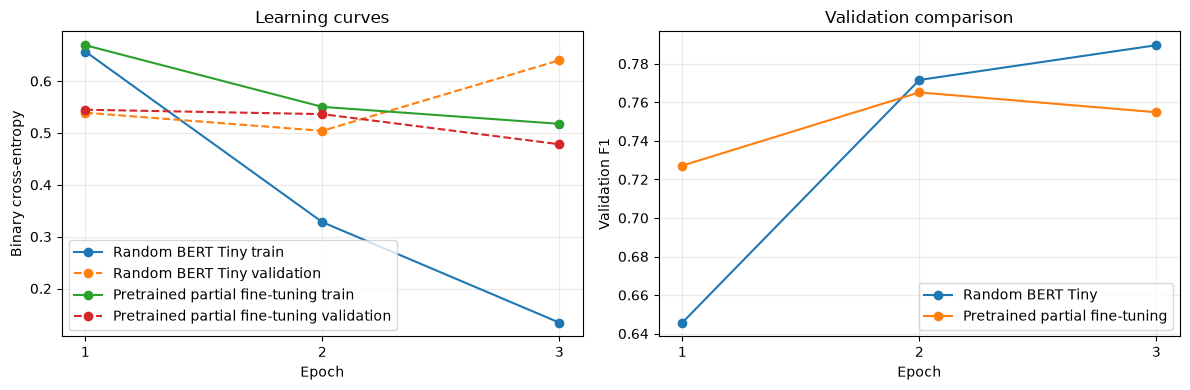

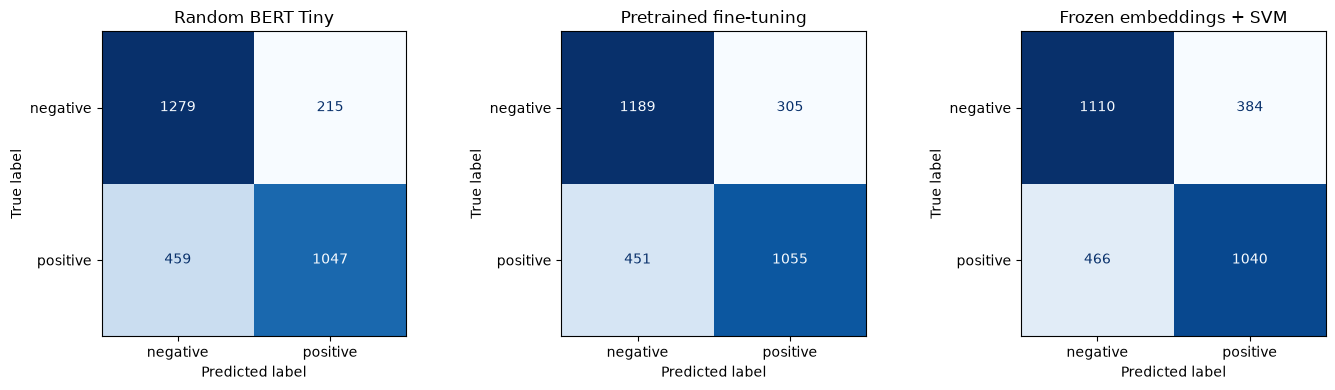

## Observations

The random BERT Tiny checkpoint selected epoch **2** and achieved held-out accuracy **0.7753**, F1 **0.7565**, and ROC AUC **0.8743**. Partial fine-tuning selected epoch **3** and achieved accuracy **0.7480**, F1 **0.7362**, and ROC AUC **0.8379**. Its accuracy difference from random initialization was **-0.0273** under the same data and architecture budget.

The frozen-embedding SVM selected `C=0.1` on validation data and achieved test accuracy **0.7167**, F1 **0.7099**, and ROC AUC **0.7862**. It is cheaper to train than end-to-end BERT after embeddings exist, but mean pooling fixes the representation before the sentiment labels are seen. The serialized embeddings occupied **5.21 MiB** and were successfully reloaded before fitting.

This is a deliberately small CPU experiment, not a claim about full-data BERT performance. The 96-token limit truncated **90.67%** of sampled test reviews, and the labeled subsets use only part of the leak-free split. Larger sequence and training budgets could change every result.

The detected system GPU was **NVIDIA GeForce RTX 3050 Ti Laptop GPU**, while PyTorch exposed CUDA as **False**. The run therefore used **cpu** with **8** CPU threads. Neural training and validation took **180.98 seconds**, frozen embedding extraction took **8.94 seconds**, and the final SVM fit took **0.62 seconds**. Neural checkpoints remained in memory; the ignored pickle is the only saved model-derived artifact.

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, history in (
    ("Random BERT Tiny", random_history),
    ("Pretrained partial fine-tuning", pretrained_history),
):
    axes[0].plot(history.index, history["train loss"], marker="o", label=f"{name} train")
    axes[0].plot(history.index, history["validation loss"], marker="o", linestyle="--", label=f"{name} validation")
    axes[1].plot(history.index, history["validation F1"], marker="o", label=name)
axes[0].set(xlabel="Epoch", ylabel="Binary cross-entropy", title="Learning curves")
axes[1].set(xlabel="Epoch", ylabel="Validation F1", title="Validation comparison")
for axis in axes:
    axis.set_xticks(range(1, EPOCHS + 1))
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, (name, predictions) in zip(
    axes,
    (
        ("Random BERT Tiny", random_predictions),
        ("Pretrained fine-tuning", pretrained_predictions),
        ("Frozen embeddings + SVM", svm_predictions),
    ),
):
    ConfusionMatrixDisplay.from_predictions(
        test_labels.astype(int),
        predictions,
        display_labels=["negative", "positive"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(name)
plt.tight_layout()
plt.show()

random_test = comparison.loc["Random BERT Tiny"]
pretrained_test = comparison.loc["Pretrained partial fine-tuning"]
svm_test = comparison.loc["Frozen embeddings + linear SVM"]
total_neural_seconds = random_diagnostics["seconds"] + pretrained_diagnostics["seconds"]
display(Markdown(
    f'''## Observations

The random BERT Tiny checkpoint selected epoch **{random_diagnostics['selected epoch']}** and achieved held-out accuracy **{random_test['accuracy']:.4f}**, F1 **{random_test['F1']:.4f}**, and ROC AUC **{random_test['ROC AUC']:.4f}**. Partial fine-tuning selected epoch **{pretrained_diagnostics['selected epoch']}** and achieved accuracy **{pretrained_test['accuracy']:.4f}**, F1 **{pretrained_test['F1']:.4f}**, and ROC AUC **{pretrained_test['ROC AUC']:.4f}**. Its accuracy difference from random initialization was **{pretrained_test['accuracy'] - random_test['accuracy']:+.4f}** under the same data and architecture budget.

The frozen-embedding SVM selected `C={best_c:g}` on validation data and achieved test accuracy **{svm_test['accuracy']:.4f}**, F1 **{svm_test['F1']:.4f}**, and ROC AUC **{svm_test['ROC AUC']:.4f}**. It is cheaper to train than end-to-end BERT after embeddings exist, but mean pooling fixes the representation before the sentiment labels are seen. The serialized embeddings occupied **{artifact_path.stat().st_size / 1024**2:.2f} MiB** and were successfully reloaded before fitting.

This is a deliberately small CPU experiment, not a claim about full-data BERT performance. The 96-token limit truncated **{np.mean(test_full_lengths > MAX_LENGTH):.2%}** of sampled test reviews, and the labeled subsets use only part of the leak-free split. Larger sequence and training budgets could change every result.

The detected system GPU was **{gpu_name}**, while PyTorch exposed CUDA as **{torch.cuda.is_available()}**. The run therefore used **{device}** with **{torch.get_num_threads()}** CPU threads. Neural training and validation took **{total_neural_seconds:.2f} seconds**, frozen embedding extraction took **{embedding_seconds:.2f} seconds**, and the final SVM fit took **{svm_seconds:.2f} seconds**. Neural checkpoints remained in memory; the ignored pickle is the only saved model-derived artifact.'''
))